# AI Semiconductor Defect Detection using LSWMD Dataset

## 1. Import Libraries

In [145]:
import pandas as pd

print("Loading dataset...")

df = pd.read_pickle("../data/LSWMD.pkl")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Loading dataset...
Dataset loaded successfully!
Shape: (811457, 6)


In [146]:
print("Columns in the dataset:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Columns in the dataset:
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')

Data Types:
waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trianTestLabel     object
failureType        object
dtype: object

Missing Values:
waferMap          0
dieSize           0
lotName           0
waferIndex        0
trianTestLabel    0
failureType       0
dtype: int64


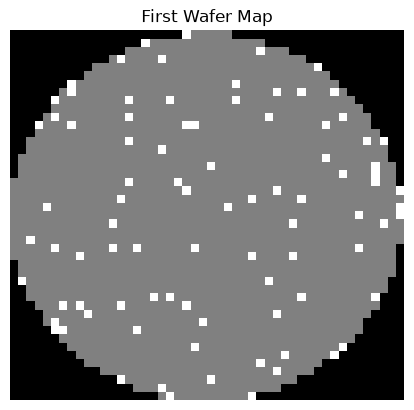

In [147]:
import matplotlib.pyplot as plt

plt.imshow(df['waferMap'][0], cmap='gray')
plt.title("First Wafer Map")
plt.axis("off")
plt.show()

In [148]:
print("Columns:")
print(df.columns)

Columns:
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [149]:
print(df.dtypes)


waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trianTestLabel     object
failureType        object
dtype: object


In [150]:
print(df.isnull().sum())


waferMap          0
dieSize           0
lotName           0
waferIndex        0
trianTestLabel    0
failureType       0
dtype: int64


In [151]:
# print(df["failureType"].value_counts())

In [152]:
df["failureType"].head()


0    [[none]]
1    [[none]]
2    [[none]]
3    [[none]]
4    [[none]]
Name: failureType, dtype: object

In [153]:
df.iloc[0]


waferMap          [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
dieSize                                                      1683.0
lotName                                                        lot1
waferIndex                                                      1.0
trianTestLabel                                         [[Training]]
failureType                                                [[none]]
Name: 0, dtype: object

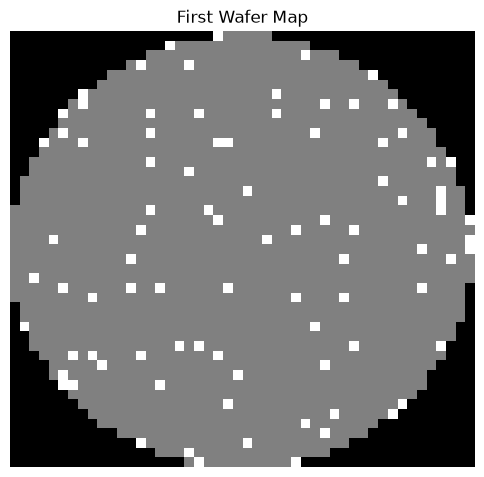

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(df.iloc[0]["waferMap"], cmap="gray")
plt.title("First Wafer Map")
plt.axis("off")
plt.show()

In [155]:
df["failureLabel"] = df["failureType"].apply(
    lambda x: x[0][0] if len(x) > 0 else "Unknown"
)

print(df["failureLabel"].value_counts())

failureLabel
Unknown      638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [156]:
print(df["failureType"].iloc[:10])

0    [[none]]
1    [[none]]
2    [[none]]
3    [[none]]
4    [[none]]
5    [[none]]
6    [[none]]
7    [[none]]
8    [[none]]
9    [[none]]
Name: failureType, dtype: object


In [157]:
print(df["failureType"].apply(len).value_counts())


failureType
0    638507
1    172950
Name: count, dtype: int64


In [158]:
df["failureLabel"] = df["failureType"].apply(
    lambda x: x[0][0] if len(x) > 0 else "Unknown"
)

print(df["failureLabel"].value_counts())

failureLabel
Unknown      638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [159]:
df_clean = df[df["failureLabel"] != "Unknown"]

print("Original Shape:", df.shape)
print("Clean Shape:", df_clean.shape)

Original Shape: (811457, 7)
Clean Shape: (172950, 7)


In [160]:
print(df_clean["failureLabel"].value_counts())


failureLabel
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [161]:
df_clean = df[df["failureLabel"] != "Unknown"]

print("Original Shape:", df.shape)
print("Clean Shape:", df_clean.shape)

Original Shape: (811457, 7)
Clean Shape: (172950, 7)


In [162]:
print(df_clean["failureLabel"].value_counts())


failureLabel
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


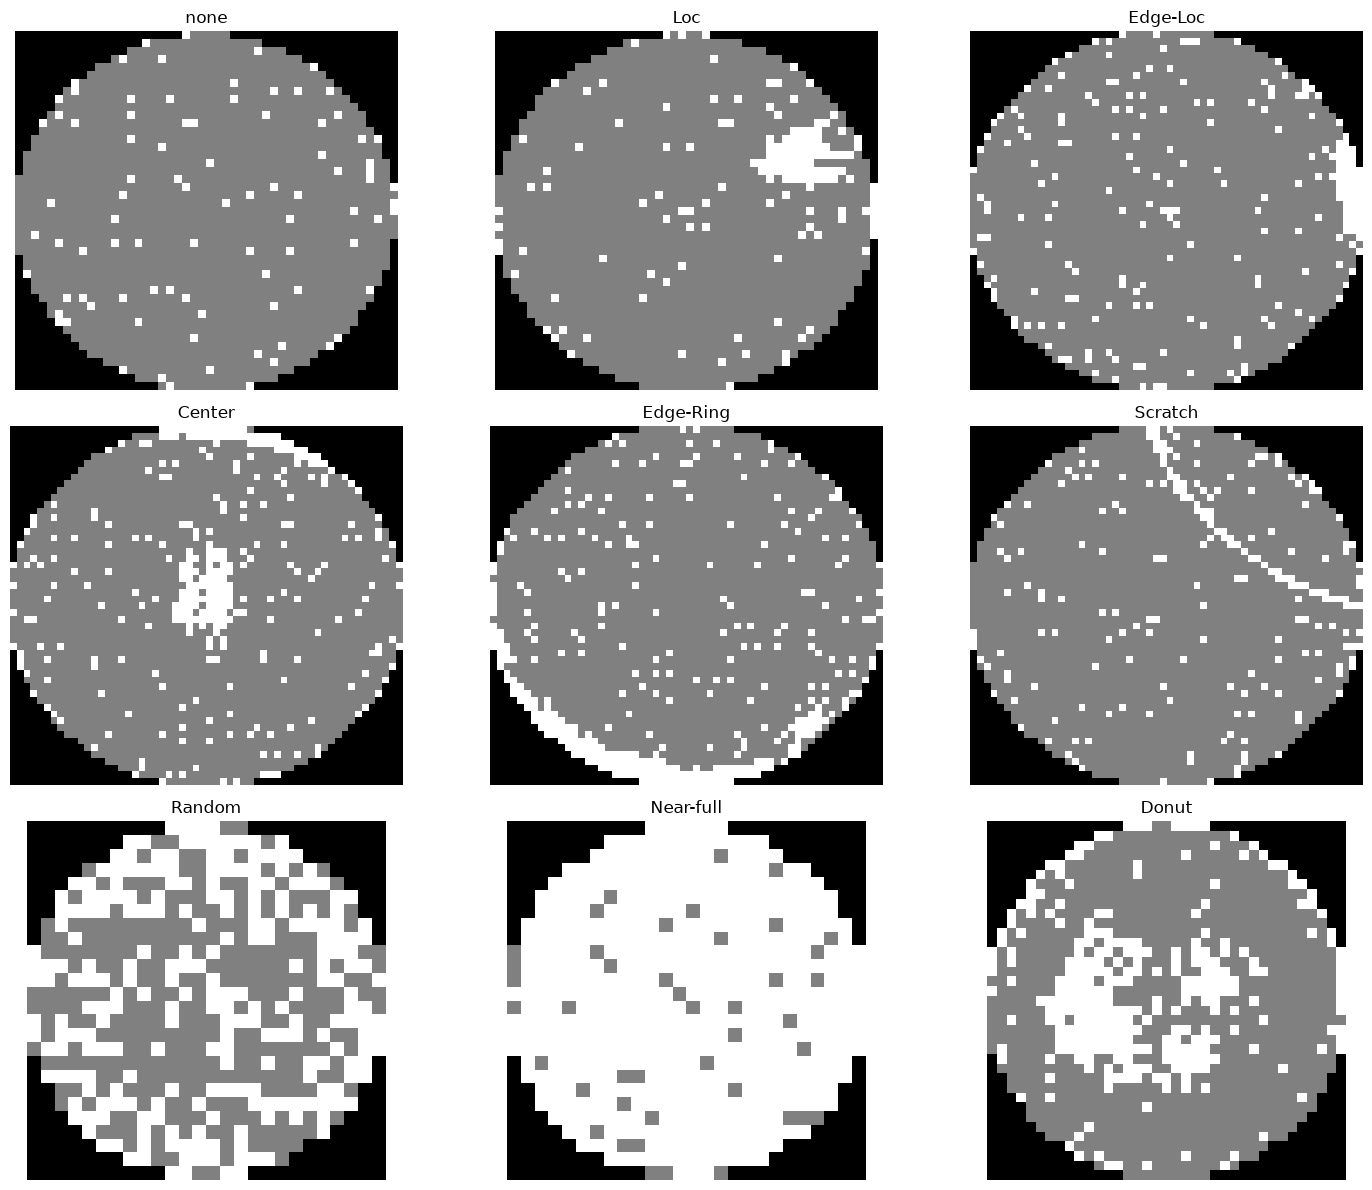

In [163]:
import matplotlib.pyplot as plt

labels = df_clean["failureLabel"].unique()

plt.figure(figsize=(15, 12))

for i, label in enumerate(labels):
    sample = df_clean[df_clean["failureLabel"] == label].iloc[0]

    plt.subplot(3, 3, i + 1)
    plt.imshow(sample["waferMap"], cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [164]:
print(df_clean["failureLabel"].unique())

[np.str_('none') np.str_('Loc') np.str_('Edge-Loc') np.str_('Center')
 np.str_('Edge-Ring') np.str_('Scratch') np.str_('Random')
 np.str_('Near-full') np.str_('Donut')]


In [165]:
import numpy as np

X = np.array(df_clean["waferMap"].tolist())
y = np.array(df_clean["failureLabel"])

print("X shape:", X.shape)
print("y shape:", y.shape)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (172950,) + inhomogeneous part.

In [ ]:
print(df_clean["waferMap"].apply(lambda x: x.shape).value_counts())


waferMap
(25, 27)    18781
(26, 26)    14366
(30, 34)    12400
(29, 26)    11751
(27, 25)    10682
            ...  
(41, 30)        1
(72, 50)        1
(71, 70)        1
(54, 54)        1
(29, 35)        1
Name: count, Length: 346, dtype: int64


In [ ]:
print(df_clean["waferMap"].apply(lambda x: x.shape).value_counts())

waferMap
(25, 27)    18781
(26, 26)    14366
(30, 34)    12400
(29, 26)    11751
(27, 25)    10682
            ...  
(41, 30)        1
(72, 50)        1
(71, 70)        1
(54, 54)        1
(29, 35)        1
Name: count, Length: 346, dtype: int64


In [ ]:
from skimage.transform import resize

In [ ]:
from skimage.transform import resize

print("scikit-image imported successfully!")

scikit-image imported successfully!


In [ ]:
sample = df_clean["waferMap"].iloc[0]

print("Original shape:", sample.shape)

resized = resize(sample, (32, 32), anti_aliasing=False)

print("Resized shape:", resized.shape)

Original shape: (45, 48)
Resized shape: (32, 32)


In [ ]:
X_small = []

for wafer in df_clean["waferMap"].iloc[:10000]:
    X_small.append(resize(wafer, (32, 32), anti_aliasing=False))

X_small = np.array(X_small)

print("Shape:", X_small.shape)

Shape: (10000, 32, 32)


In [ ]:
y_small= df_clean["failureLabel"].iloc[:10000]

print(y_small.value_counts())

failureLabel
none         6386
Edge-Ring    1587
Edge-Loc      978
Loc           488
Random        206
Center        197
Scratch        90
Donut          60
Near-full       8
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_small_encoded = encoder.fit_transform(y_small)

print("Original Labels:")
print(y_small.unique())

print("\nEncoded Labels:")
print(y_small_encoded[:20])

Original Labels:
[np.str_('none') np.str_('Loc') np.str_('Edge-Loc') np.str_('Center')
 np.str_('Edge-Ring') np.str_('Scratch') np.str_('Random')
 np.str_('Near-full') np.str_('Donut')]

Encoded Labels:
[8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 4]


In [ ]:
print("Label Mapping:")

for label, number in zip(encoder.classes_, range(len(encoder.classes_))):
    print(f"{label} --> {number}")

Label Mapping:
Center --> 0
Donut --> 1
Edge-Loc --> 2
Edge-Ring --> 3
Loc --> 4
Near-full --> 5
Random --> 6
Scratch --> 7
none --> 8


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small_encoded,
    test_size=0.2,
    random_state=42
)

print("Training images:", X_train.shape)
print("Testing images :", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels :", y_test.shape)

Training images: (8000, 32, 32)
Testing images : (2000, 32, 32)
Training labels: (8000,)
Testing labels : (2000,)


In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Training shape:", X_train_flat.shape)
print("Testing shape:", X_test_flat.shape)

Training shape: (8000, 1024)
Testing shape: (2000, 1024)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_flat, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_flat)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.957


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.74      0.85        43
           1       1.00      0.47      0.64        15
           2       0.84      0.90      0.87       201
           3       0.99      0.98      0.99       330
           4       0.88      0.80      0.84        85
           5       1.00      1.00      1.00         1
           6       0.97      0.80      0.88        41
           7       1.00      0.21      0.35        14
           8       0.97      1.00      0.98      1270

    accuracy                           0.96      2000
   macro avg       0.96      0.77      0.82      2000
weighted avg       0.96      0.96      0.95      2000



In [134]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_small_encoded = encoder.fit_transform(y_small)

print("Number of labels:", len(y_small_encoded))

Number of labels: 10000


In [135]:
print(len(X_small))
print(len(y_small_encoded))

10000
10000


In [136]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_flat, y_train)

print("Model trained successfully!")

Model trained successfully!


In [137]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_flat)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.957

              precision    recall  f1-score   support

           0       1.00      0.74      0.85        43
           1       1.00      0.47      0.64        15
           2       0.84      0.90      0.87       201
           3       0.99      0.98      0.99       330
           4       0.88      0.80      0.84        85
           5       1.00      1.00      1.00         1
           6       0.97      0.80      0.88        41
           7       1.00      0.21      0.35        14
           8       0.97      1.00      0.98      1270

    accuracy                           0.96      2000
   macro avg       0.96      0.77      0.82      2000
weighted avg       0.96      0.96      0.95      2000



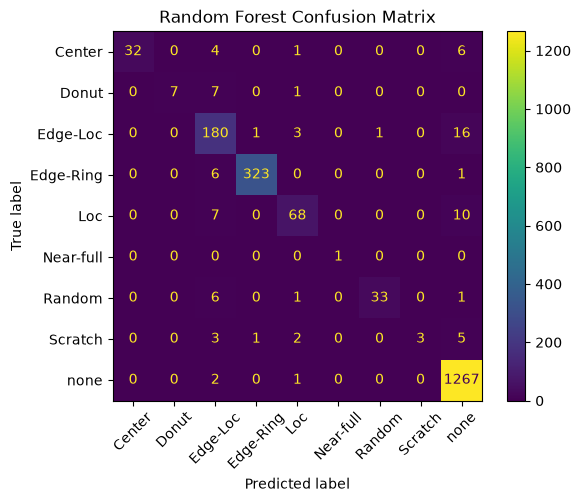

In [138]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=encoder.classes_,
    xticks_rotation=45
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [139]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [140]:
# Convert images to float and normalize pixel values

X_small = X_small.astype("float32")

# Normalize values between 0 and 1
X_small = X_small / X_small.max()

# Add channel dimension
X_small = X_small.reshape(-1, 32, 32, 1)

print("New Shape:", X_small.shape)
print("Maximum Pixel Value:", X_small.max())
print("Minimum Pixel Value:", X_small.min())

New Shape: (10000, 32, 32, 1)
Maximum Pixel Value: 1.0
Minimum Pixel Value: 0.0


In [141]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [142]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(9, activation='softmax'))

print("CNN Model Created Successfully!")

c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Created Successfully!


In [143]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,017 (1.20 MB)

 Trainable params: 315,017 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [144]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Compiled Successfully!")

CNN Compiled Successfully!


In [96]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6351 - loss: 1.2939 - val_accuracy: 0.6350 - val_loss: 1.1911
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6395 - loss: 1.2266 - val_accuracy: 0.6350 - val_loss: 1.1967
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6395 - loss: 1.2212 - val_accuracy: 0.6350 - val_loss: 1.1954
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6395 - loss: 1.2131 - val_accuracy: 0.6350 - val_loss: 1.1892
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6395 - loss: 1.2132 - val_accuracy: 0.6350 - val_loss: 1.1914
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6395 - loss: 1.2105 - val_accuracy: 0.6350 - val_loss: 1.1922
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6395 - loss: 1.2105 - val_accuracy: 0.6350 - val_loss: 1.1913
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6395 - loss: 1.2117 - val_accu

In [97]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("CNN Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6350 - loss: 1.2010
CNN Accuracy: 0.6349999904632568


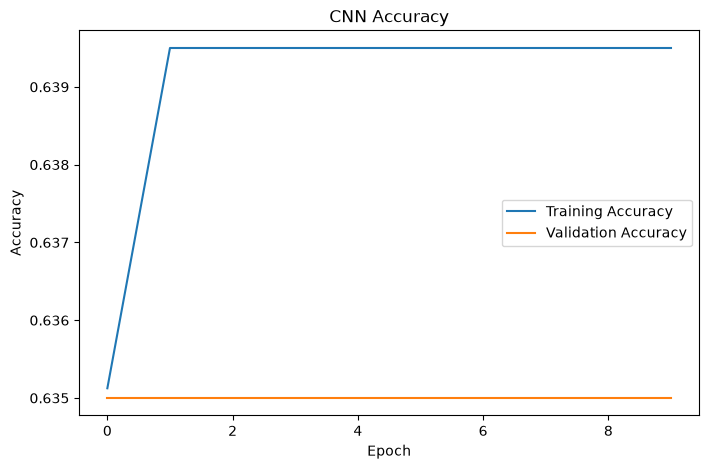

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

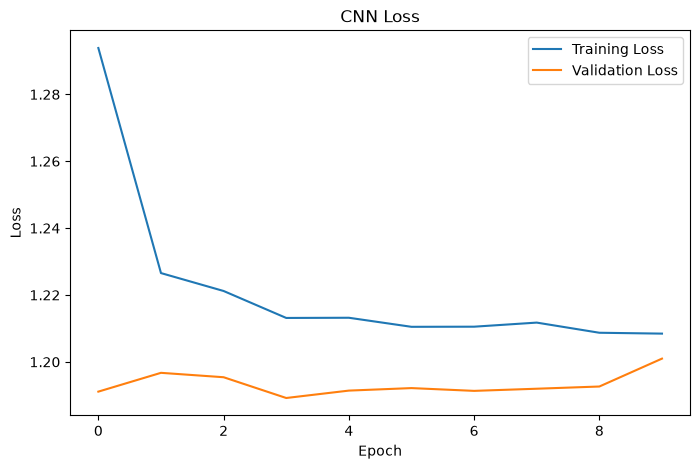

In [99]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [100]:
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [101]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.00      0.00      0.00        15
           2       0.00      0.00      0.00       201
           3       0.00      0.00      0.00       330
           4       0.00      0.00      0.00        85
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00        41
           7       0.00      0.00      0.00        14
           8       0.64      1.00      0.78      1270

    accuracy                           0.64      2000
   macro avg       0.07      0.11      0.09      2000
weighted avg       0.40      0.64      0.49      2000



c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

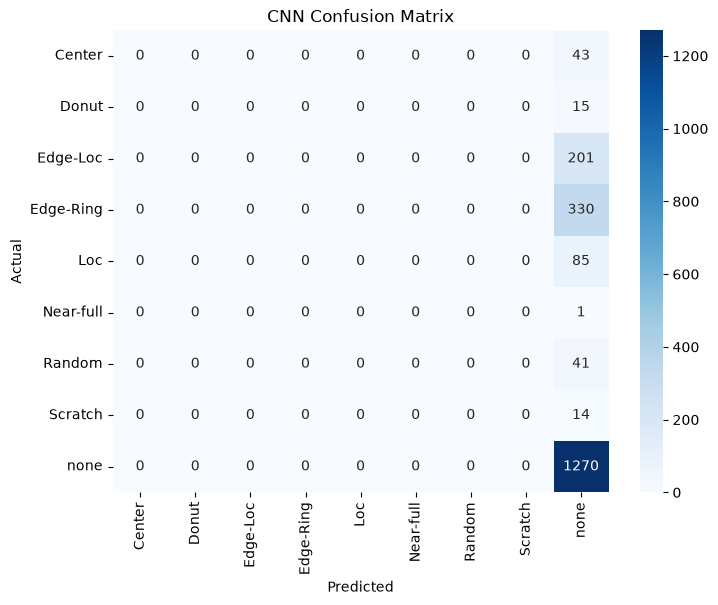

In [102]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

In [103]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(5.772005772005772), 1: np.float64(19.753086419753085), 2: np.float64(1.144001144001144), 3: np.float64(0.7071510651462919), 4: np.float64(2.2056796250344637), 5: np.float64(126.98412698412699), 6: np.float64(5.3872053872053876), 7: np.float64(11.695906432748538), 8: np.float64(0.17374685083832855)}


In [104]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6395 - loss: 2.2628 - val_accuracy: 0.6350 - val_loss: 1.9791
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6385 - loss: 2.2155 - val_accuracy: 0.6350 - val_loss: 2.0436
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6274 - loss: 2.2119 - val_accuracy: 0.6350 - val_loss: 2.0953
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4581 - loss: 2.1972 - val_accuracy: 0.6350 - val_loss: 2.1224
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3930 - loss: 2.2048 - val_accuracy: 0.6350 - val_loss: 2.1324
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.3625 - loss: 2.1997 - val_accuracy: 0.6350 - val_loss: 2.1437
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.3536 - loss: 2.2032 - val_accuracy: 0.6350 - val_loss: 2.1506
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.3505 - loss: 2.2025 - val_accu

In [105]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(5.772005772005772), 1: np.float64(19.753086419753085), 2: np.float64(1.144001144001144), 3: np.float64(0.7071510651462919), 4: np.float64(2.2056796250344637), 5: np.float64(126.98412698412699), 6: np.float64(5.3872053872053876), 7: np.float64(11.695906432748538), 8: np.float64(0.17374685083832855)}


In [106]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(9, activation='softmax'))

c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [107]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,017 (1.20 MB)

 Trainable params: 315,017 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [108]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [109]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.1213 - loss: 2.2326 - val_accuracy: 0.0425 - val_loss: 2.1762
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0879 - loss: 2.2105 - val_accuracy: 0.0425 - val_loss: 2.1764
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.0786 - loss: 2.2035 - val_accuracy: 0.0070 - val_loss: 2.1902
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.0693 - loss: 2.2028 - val_accuracy: 0.0425 - val_loss: 2.1951
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.0622 - loss: 2.1999 - val_accuracy: 0.0075 - val_loss: 2.1946
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.0374 - loss: 2.2038 - val_accuracy: 0.0075 - val_loss: 2.2009
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.0244 - loss: 2.1989 - val_accuracy: 0.0075 - val_loss: 2.1994
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.0896 - loss: 2.1989 - val

In [110]:
print(X_train.shape)
print(y_train.shape)

(8000, 32, 32, 1)
(8000,)


In [111]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.0804 - loss: 2.2002 - val_accuracy: 0.0070 - val_loss: 2.1960
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.0435 - loss: 2.2014 - val_accuracy: 5.0000e-04 - val_loss: 2.2023
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.0755 - loss: 2.1984 - val_accuracy: 5.0000e-04 - val_loss: 2.2020
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.0250 - loss: 2.1979 - val_accuracy: 0.0075 - val_loss: 2.2007
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.0161 - loss: 2.1982 - val_accuracy: 0.0075 - val_loss: 2.1980
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0196 - loss: 2.1981 - val_accuracy: 0.0075 - val_loss: 2.1978
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.0311 - loss: 2.1997 - val_accuracy: 0.0075 - val_loss: 2.1981
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.0220 - loss: 2.1986 -

In [112]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Improved CNN Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 5.0000e-04 - loss: 2.2003
Improved CNN Accuracy: 0.0005000000237487257


In [113]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Improved CNN Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 5.0000e-04 - loss: 2.2003
Improved CNN Accuracy: 0.0005000000237487257


In [114]:
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


In [115]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.00      0.00      0.00        15
           2       0.00      0.00      0.00       201
           3       0.00      0.00      0.00       330
           4       0.00      0.00      0.00        85
           5       0.00      1.00      0.00         1
           6       0.00      0.00      0.00        41
           7       0.00      0.00      0.00        14
           8       0.00      0.00      0.00      1270

    accuracy                           0.00      2000
   macro avg       0.00      0.11      0.00      2000
weighted avg       0.00      0.00      0.00      2000



c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

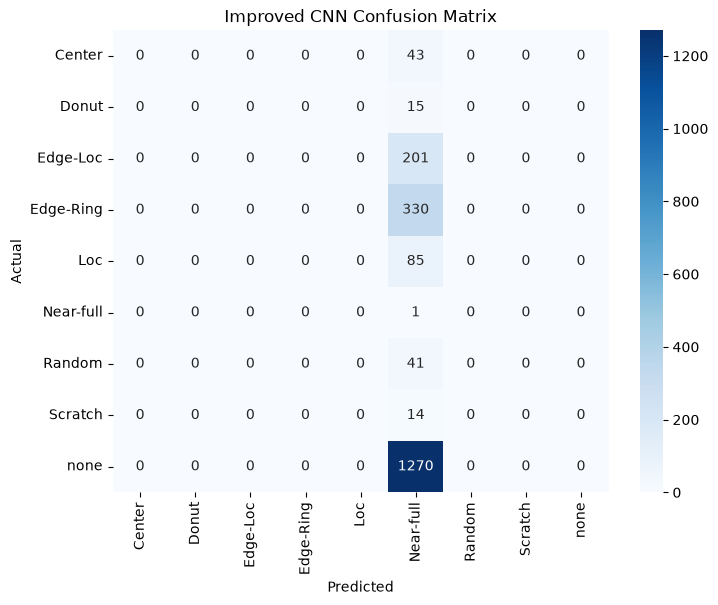

In [116]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Improved CNN Confusion Matrix")
plt.show()

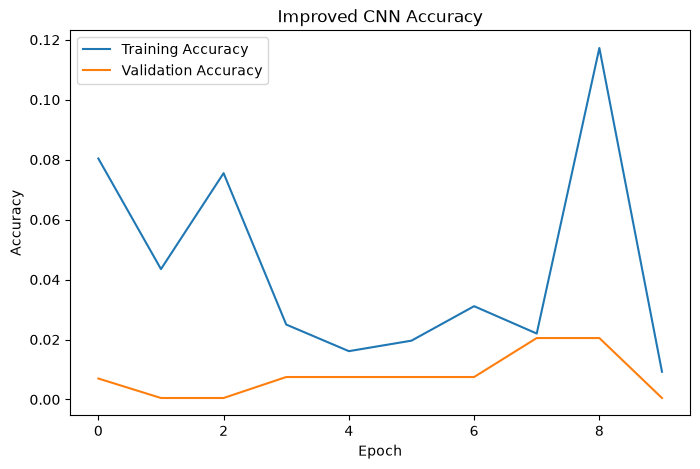

In [117]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Improved CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

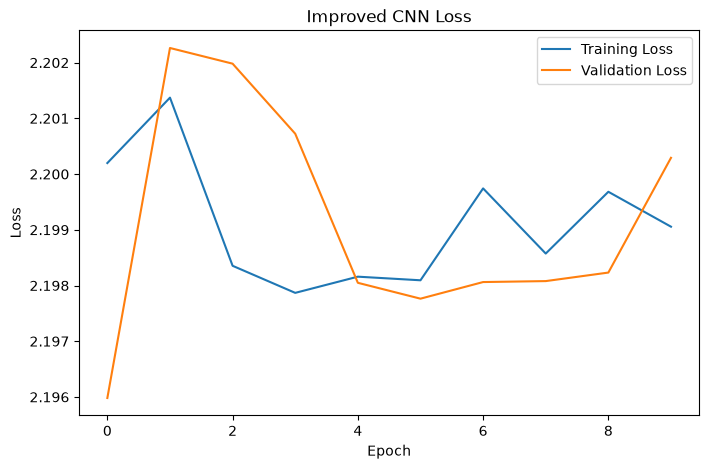

In [118]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Improved CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [119]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Improved CNN Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 5.0000e-04 - loss: 2.2003
Improved CNN Accuracy: 0.0005000000237487257


In [120]:
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [121]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.00      0.00      0.00        15
           2       0.00      0.00      0.00       201
           3       0.00      0.00      0.00       330
           4       0.00      0.00      0.00        85
           5       0.00      1.00      0.00         1
           6       0.00      0.00      0.00        41
           7       0.00      0.00      0.00        14
           8       0.00      0.00      0.00      1270

    accuracy                           0.00      2000
   macro avg       0.00      0.11      0.00      2000
weighted avg       0.00      0.00      0.00      2000



c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

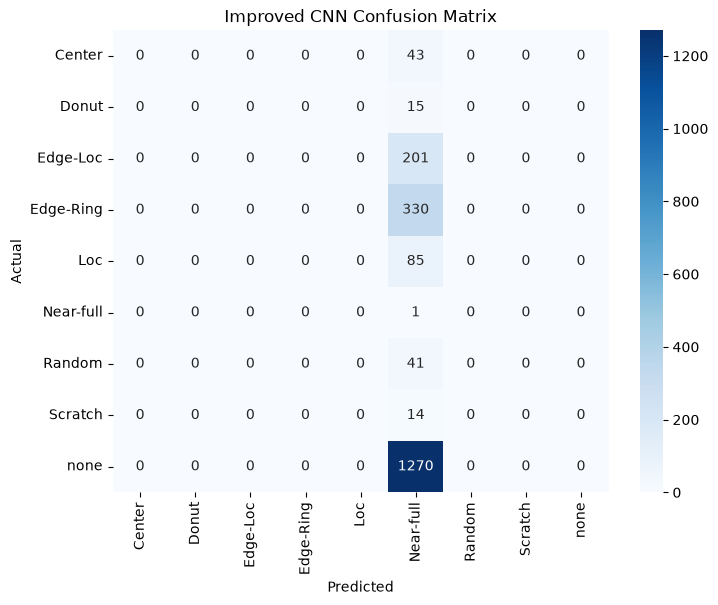

In [122]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Improved CNN Confusion Matrix")
plt.show()

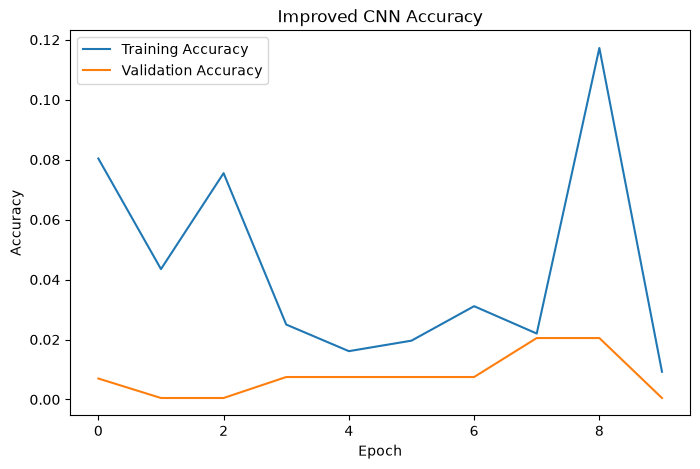

In [123]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Improved CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

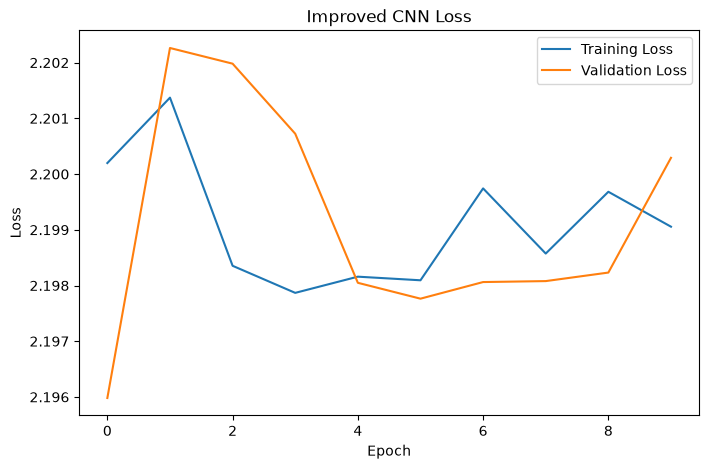

In [124]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Improved CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [125]:
print(y_train.shape)
print(y_test.shape)

(8000,)
(2000,)


In [126]:
print(y_train[:5])

[0 8 8 8 8]


In [127]:
model.loss

'sparse_categorical_crossentropy'

In [128]:
print("Before normalization")
print("Shape:", X_small.shape)
print("Min:", X_small.min())
print("Max:", X_small.max())
print("Unique values:", np.unique(X_small)[:20])

Before normalization
Shape: (10000, 32, 32, 1)
Min: 0.0
Max: 1.0
Unique values: [0.         0.00061035 0.00073242 0.00085449 0.00097656 0.00109863
 0.0012207  0.00146484 0.00158691 0.00170898 0.00183105 0.00195312
 0.0020752  0.00219727 0.00231934 0.00244141 0.00256348 0.00268555
 0.00292969 0.00305176]


In [129]:
X_small = X_small.astype("float32") / 255.0

X_small = X_small.reshape(-1, 32, 32, 1)

In [130]:
print("After normalization")
print("Shape:", X_small.shape)
print("Min:", X_small.min())
print("Max:", X_small.max())
print("Unique values:", np.unique(X_small)[:20])

After normalization
Shape: (10000, 32, 32, 1)
Min: 0.0
Max: 0.003921569
Unique values: [0.0000000e+00 2.3935356e-06 2.8722427e-06 3.3509493e-06 3.8296571e-06
 4.3083642e-06 4.7870712e-06 5.7444854e-06 6.2231916e-06 6.7018987e-06
 7.1806057e-06 7.6593142e-06 8.1380213e-06 8.6167283e-06 9.0954354e-06
 9.5741425e-06 1.0052850e-05 1.0531557e-05 1.1488971e-05 1.1967676e-05]


In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small_encoded,
    test_size=0.2,
    random_state=42
)

In [132]:
print(X_train.shape)
print(X_test.shape)

print(X_train.min(), X_train.max())
print(X_test.min(), X_test.max())

(8000, 32, 32, 1)
(2000, 32, 32, 1)
0.0 0.003921569
0.0 0.003921569


In [133]:
print(X_small.dtype)

float32


In [166]:
print("X_small shape:", X_small.shape)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_small shape: (10000, 32, 32, 1)
X_train shape: (8000, 32, 32, 1)
y_train shape: (8000,)


In [167]:
print("Unique labels:", np.unique(y_train))

Unique labels: [0 1 2 3 4 5 6 7 8]


In [168]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [169]:
print(history.history["accuracy"])

[0.08037500083446503, 0.04349999874830246, 0.0754999965429306, 0.02500000037252903, 0.016124999150633812, 0.019625000655651093, 0.03112499974668026, 0.02199999988079071, 0.1172500029206276, 0.00925000011920929]


In [170]:
print(history.history["val_accuracy"])

[0.007000000216066837, 0.0005000000237487257, 0.0005000000237487257, 0.007499999832361937, 0.007499999832361937, 0.007499999832361937, 0.007499999832361937, 0.020500000566244125, 0.020500000566244125, 0.0005000000237487257]


In [171]:
print(df_clean.head())

                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex trianTestLabel failureType failureLabel  
0         1.0   [[Training]]    [[none]]         none  
1         2.0   [[Training]]    [[none]]         none  
2         3.0   [[Training]]    [[none]]         none  
3         4.0   [[Training]]    [[none]]         none  
4         5.0   [[Training]]    [[none]]         none  


In [172]:
print(df_clean["failureLabel"].head(10))

0    none
1    none
2    none
3    none
4    none
5    none
6    none
7    none
8    none
9    none
Name: failureLabel, dtype: object


In [173]:
print(df_clean["failureLabel"].iloc[0])
print(type(df_clean["failureLabel"].iloc[0]))

none
<class 'numpy.str_'>


In [174]:
print(y_small.value_counts())

failureLabel
none         6386
Edge-Ring    1587
Edge-Loc      978
Loc           488
Random        206
Center        197
Scratch        90
Donut          60
Near-full       8
Name: count, dtype: int64
